# Solver Stability Extension: Ill Conditioned Regression on `iris.csv`


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import data
import linear_regression

## Init


In [2]:
# import the dataset
iris_data = data.Data('data/iris.csv')
print(iris_data)
print('Headers:', iris_data.get_headers())
print('Number of samples:', iris_data.get_num_samples())

x_base = iris_data.select_data(['sepal_length']).ravel()
y = iris_data.select_data(['petal_length']).ravel()

-------------------------------
data/iris.csv (150x5)
Headers:
  sepal_length	sepal_width	petal_length	petal_width	species
-------------------------------
Showing first 5/150 rows.
5.1	3.5	1.4	0.2	0.0
4.9	3.0	1.4	0.2	0.0
4.7	3.2	1.3	0.2	0.0
4.6	3.1	1.5	0.2	0.0
5.0	3.6	1.4	0.2	0.0

-------------------------------
Headers: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Number of samples: 150


## Build Near-Duplicate Predictors


In [3]:
epsilon_values = [1, 1e-1, 1e-2, 1e-4, 1e-6, 0]
epsilon_labels = ['1', '1e-1', '1e-2', '1e-4', '1e-6', '0']

rng = np.random.default_rng(0)
duplicate_noise = rng.normal(0.0, 1.0, size=x_base.shape[0])


def make_duplicate_feature(x, epsilon):
    if epsilon == 0:
        return x.copy()
    return x + epsilon * duplicate_noise


for eps in epsilon_values[:3]:
    x_copy = make_duplicate_feature(x_base, eps)
    max_difference = np.max(np.abs(x_copy - x_base))
    print(f'epsilon={eps:g}: max |copy - original| = {max_difference:.4f}')

epsilon=1: max |copy - original| = 2.3653
epsilon=0.1: max |copy - original| = 0.2365
epsilon=0.01: max |copy - original| = 0.0237


## Condition Number Helper


In [4]:
def make_dataset_with_duplicate(epsilon):
    x_copy = make_duplicate_feature(x_base, epsilon)
    combined = np.column_stack([x_base, x_copy, y])
    return data.Data(
        headers=['sepal_length', 'sepal_length_copy', 'petal_length'],
        data=combined,
        header2col={'sepal_length': 0, 'sepal_length_copy': 1, 'petal_length': 2},
    )



def augmented_condition_number(dataset):
    predictors = dataset.select_data(['sepal_length', 'sepal_length_copy'])
    augmented = np.column_stack([predictors, np.ones(predictors.shape[0])])
    return float(np.linalg.cond(augmented))


example_dataset = make_dataset_with_duplicate(1e-2)
print('Example condition number at epsilon=1e-2:', f'{augmented_condition_number(example_dataset):.3e}')

Example condition number at epsilon=1e-2: 1.241e+03


## Compare Normal Equations And QR


In [5]:
def run_regression(dataset, method):
    model = linear_regression.LinearRegression(dataset)
    model.linear_regression(['sepal_length', 'sepal_length_copy'], 'petal_length', method=method)
    slope_values = model.get_fitted_slope().ravel()
    return {
        'model': model,
        'slope_sepal_length': float(slope_values[0]),
        'slope_sepal_length_copy': float(slope_values[1]),
        'intercept': float(model.get_fitted_intercept()),
        'R2': float(model.R2),
        'MSE': float(model.mse),
    }


results = []
saved_cases = {}

for epsilon in epsilon_values:
    dataset_eps = make_dataset_with_duplicate(epsilon)
    condition_value = augmented_condition_number(dataset_eps)

    if epsilon in (1, 1e-6):
        saved_cases[epsilon] = {'dataset': dataset_eps, 'condition_number': condition_value}

    for method in ['normal', 'qr']:
        row = {
            'epsilon': epsilon,
            'condition_number': condition_value,
            'solver': method,
            'status': 'ok',
            'error': '',
        }

        try:
            fit_result = run_regression(dataset_eps, method)
            row.update(fit_result)
            if epsilon in saved_cases:
                saved_cases[epsilon][method] = fit_result['model']
        except Exception as err:
            row.update({
                'slope_sepal_length': np.nan,
                'slope_sepal_length_copy': np.nan,
                'intercept': np.nan,
                'R2': np.nan,
                'MSE': np.nan,
                'status': 'error',
                'error': f'{type(err).__name__}: {err}',
            })

        results.append(row)

print(f'Total solver runs recorded: {len(results)}')

Total solver runs recorded: 12


## Results Table


In [6]:
header = (
    f"{'eps':>8} {'cond':>12} {'solver':>8} "
    f"{'beta_1':>13} {'beta_2':>13} {'intercept':>12} "
    f"{'R2':>9} {'MSE':>10} {'status':>10}"
)
print(header)
print('-' * len(header))

for row in results:
    print(
        f"{row['epsilon']:>8g} "
        f"{row['condition_number']:>12.3e} "
        f"{row['solver']:>8} "
        f"{row['slope_sepal_length']:>13.3e} "
        f"{row['slope_sepal_length_copy']:>13.3e} "
        f"{row['intercept']:>12.3e} "
        f"{row['R2']:>9.4f} "
        f"{row['MSE']:>10.4f} "
        f"{row['status']:>10}"
    )

print('\nErrors recorded during the sweep:')
for row in results:
    if row['status'] == 'error':
        print(f"epsilon={row['epsilon']:g}, solver={row['solver']}: {row['error']}")

     eps         cond   solver        beta_1        beta_2    intercept        R2        MSE     status
-------------------------------------------------------------------------------------------------------
       1    6.145e+01   normal     1.836e+00     2.371e-02   -7.110e+00    0.7601     0.7425         ok
       1    6.145e+01       qr     1.836e+00     2.371e-02   -7.110e+00    0.7601     0.7425         ok
     0.1    1.241e+02   normal     1.623e+00     2.371e-01   -7.110e+00    0.7601     0.7425         ok
     0.1    1.241e+02       qr     1.623e+00     2.371e-01   -7.110e+00    0.7601     0.7425         ok
    0.01    1.241e+03   normal    -5.110e-01     2.371e+00   -7.110e+00    0.7601     0.7425         ok
    0.01    1.241e+03       qr    -5.110e-01     2.371e+00   -7.110e+00    0.7601     0.7425         ok
  0.0001    1.241e+05   normal    -2.352e+02     2.371e+02   -7.110e+00    0.7601     0.7425         ok
  0.0001    1.241e+05       qr    -2.352e+02     2.371e+02   -7.

## Plot 1: Real Relationship In The Provided Dataset


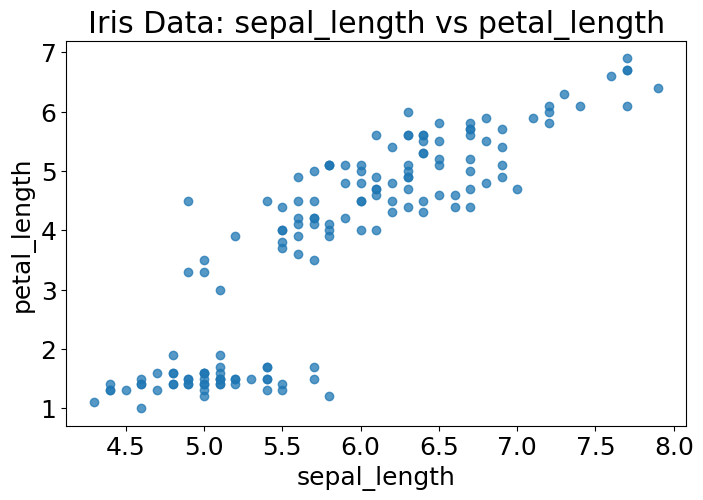

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(x_base, y, alpha=0.75)
plt.title('Iris Data: sepal_length vs petal_length')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.show()

## Plots 2 And 3: Condition Number And Coefficient Magnitude


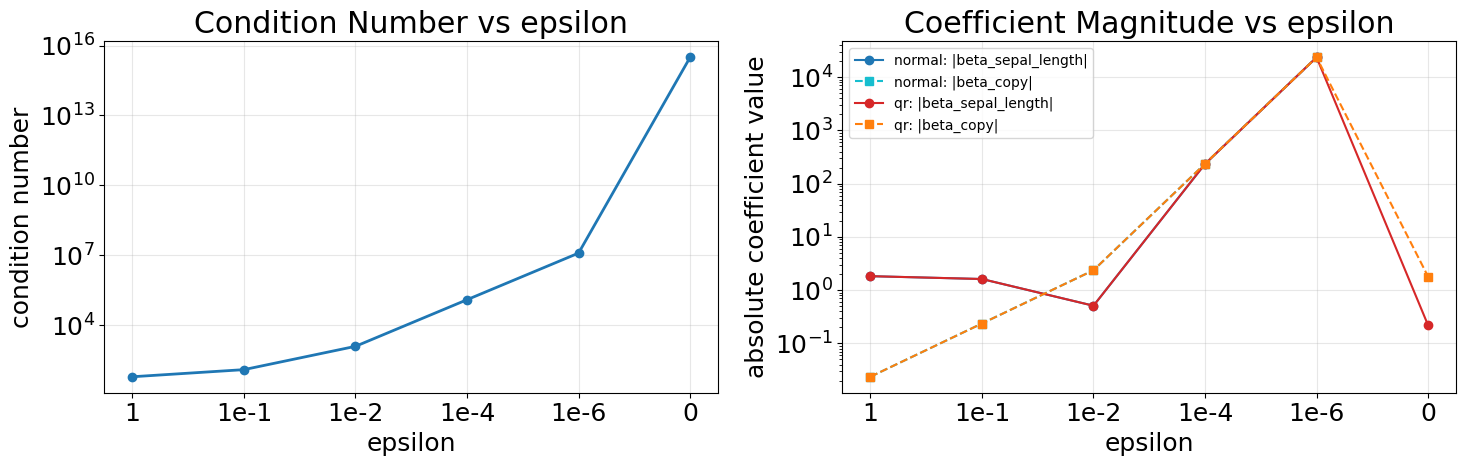

In [8]:
position_map = {epsilon: index for index, epsilon in enumerate(epsilon_values)}
condition_lookup = {}
for row in results:
    condition_lookup[row['epsilon']] = row['condition_number']

condition_values = [condition_lookup[epsilon] for epsilon in epsilon_values]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(range(len(epsilon_values)), condition_values, marker='o', linewidth=2)
axes[0].set_xticks(range(len(epsilon_values)), epsilon_labels)
axes[0].set_yscale('log')
axes[0].set_title('Condition Number vs epsilon')
axes[0].set_xlabel('epsilon')
axes[0].set_ylabel('condition number')
axes[0].grid(True, alpha=0.3)

for method, color_a, color_b in [('normal', 'tab:blue', 'tab:cyan'), ('qr', 'tab:red', 'tab:orange')]:
    rows_by_epsilon = {row['epsilon']: row for row in results if row['solver'] == method}
    beta_1_magnitudes = []
    beta_2_magnitudes = []

    for epsilon in epsilon_values:
        row = rows_by_epsilon[epsilon]
        if row['status'] == 'ok':
            beta_1_magnitudes.append(abs(row['slope_sepal_length']))
            beta_2_magnitudes.append(abs(row['slope_sepal_length_copy']))
        else:
            beta_1_magnitudes.append(np.nan)
            beta_2_magnitudes.append(np.nan)

    axes[1].plot(range(len(epsilon_values)), beta_1_magnitudes, marker='o', color=color_a,
                 label=f'{method}: |beta_sepal_length|')
    axes[1].plot(range(len(epsilon_values)), beta_2_magnitudes, marker='s', linestyle='--', color=color_b,
                 label=f'{method}: |beta_copy|')

axes[1].set_xticks(range(len(epsilon_values)), epsilon_labels)
axes[1].set_yscale('log')
axes[1].set_title('Coefficient Magnitude vs epsilon')
axes[1].set_xlabel('epsilon')
axes[1].set_ylabel('absolute coefficient value')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## Plot 4: Stable And Unstable Prediction Comparison


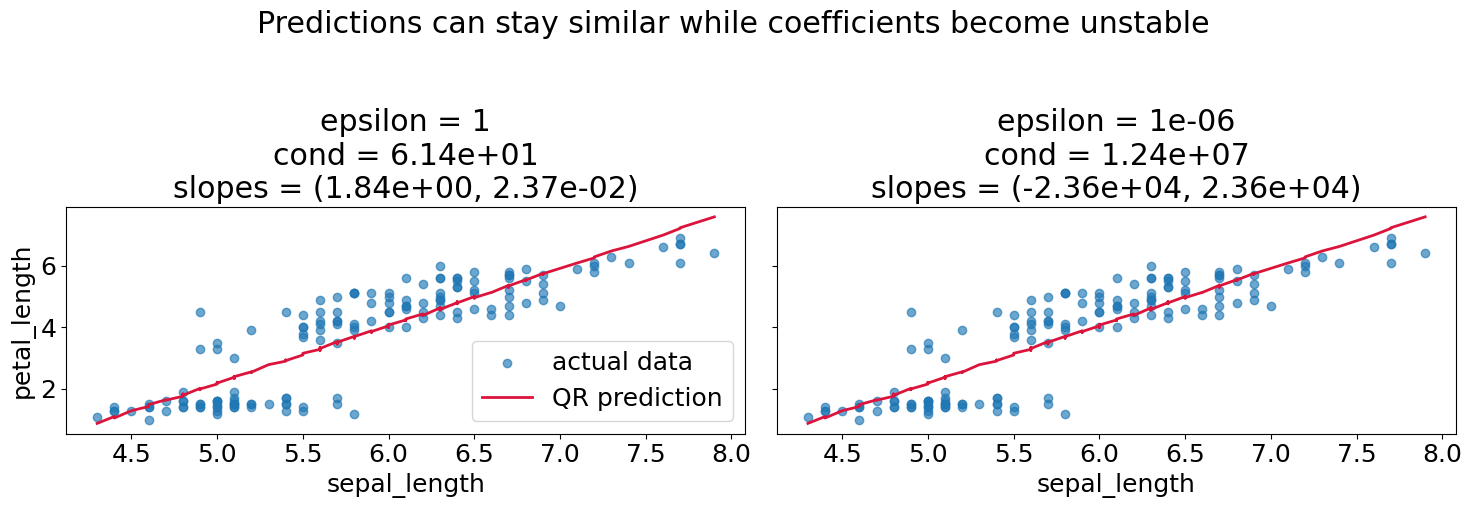

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, epsilon in zip(axes, [1, 1e-6]):
    dataset_eps = saved_cases[epsilon]['dataset']
    qr_model = saved_cases[epsilon]['qr']

    x_plot = dataset_eps.select_data(['sepal_length']).ravel()
    y_plot = dataset_eps.select_data(['petal_length']).ravel()
    predictor_matrix = dataset_eps.select_data(['sepal_length', 'sepal_length_copy'])
    y_pred = qr_model.predict(predictor_matrix).ravel()

    order = np.argsort(x_plot)
    slopes = qr_model.get_fitted_slope().ravel()

    ax.scatter(x_plot, y_plot, alpha=0.65, label='actual data')
    ax.plot(x_plot[order], y_pred[order], color='crimson', linewidth=2, label='QR prediction')
    ax.set_title(
        f'epsilon = {epsilon:g}\n'
        f'cond = {saved_cases[epsilon]["condition_number"]:.2e}\n'
        f'slopes = ({slopes[0]:.2e}, {slopes[1]:.2e})'
    )
    ax.set_xlabel('sepal_length')

axes[0].set_ylabel('petal_length')
axes[0].legend()
plt.suptitle('Predictions can stay similar while coefficients become unstable', y=1.03)
plt.tight_layout()
plt.show()
